# 02. Harmony — the Classic Baseline

Notebook 01 showed a clear batch effect: plate-based technologies (celseq, celseq2,
smarter, smartseq2) sit off on their own on the UMAP, away from the droplet-based main
cloud, despite sharing the same cell types.

**Roughly how Harmony works**: it's not a neural network, it's an iterative correction.
Cluster the data as-is, check whether each cluster has a reasonable mix of batches or is
dominated by one, nudge the under-represented batch's points toward the cluster center,
repeat. A handful of iterations later it (usually) converges.

The important difference from scVI, which comes next: Harmony corrects coordinates *on
top of* an already-computed PCA. It doesn't learn anything from scratch, which is exactly
why it's fast, deterministic, and a sensible thing to use as a baseline.

Reference: Korsunsky I. et al., "Fast, sensitive and accurate integration of single-cell
data with Harmony", Nature Methods 2019.


In [1]:
import sys
sys.path.append("../src")

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

sc.settings.verbosity = 1
print(f"scanpy: {sc.__version__}")

scanpy: 1.12.2


C:\Users\gkuzcmidzm03\AppData\Local\Temp\ipykernel_29240\2520178268.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy: {sc.__version__}")


## 1. Loading the prepared data

We take the file saved at the end of `01_qc_eda.ipynb` — the full gene set, without any
integration applied.

In [2]:
adata = sc.read("../data/processed/pancreas_prepared.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 16382 × 19093
    obs: 'tech', 'celltype', 'size_factors'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg'
    layers: 'counts', None (.X)


## 2. HVG selection and PCA — exactly as in the baseline (01), for a fair comparison

It's important to use the same gene set and the same "pre-correction" PCA as in notebook
01 — otherwise the "before / after" comparison would be unfair (the difference could
simply come from a different gene set, not from Harmony).

In [3]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="tech", subset=False)
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=30)
print("Pre-correction PCA ready:", adata_hvg.obsm["X_pca"].shape)

Pre-correction PCA ready: (16382, 30)


## 3. Running Harmony

`sc.external.pp.harmony_integrate` takes the already-computed `X_pca` and creates a
corrected version `X_pca_harmony` — the same 30 components, but with batches "evened out".
The original `X_pca` is left untouched — we can always go back and compare.

In [4]:
sc.external.pp.harmony_integrate(adata_hvg, key="tech")
print("Done. adata_hvg.obsm['X_pca_harmony'] created:", adata_hvg.obsm["X_pca_harmony"].shape)

2026-09-10 18:34:07,993 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-09-10 18:34:10,970 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-09-10 18:34:11,057 - harmonypy - INFO - Iteration 1 of 10
2026-09-10 18:34:14,839 - harmonypy - INFO - Iteration 2 of 10
2026-09-10 18:34:18,892 - harmonypy - INFO - Iteration 3 of 10
2026-09-10 18:34:22,874 - harmonypy - INFO - Iteration 4 of 10
2026-09-10 18:34:26,975 - harmonypy - INFO - Iteration 5 of 10
2026-09-10 18:34:31,006 - harmonypy - INFO - Iteration 6 of 10
2026-09-10 18:34:35,002 - harmonypy - INFO - Iteration 7 of 10
2026-09-10 18:34:39,043 - harmonypy - INFO - Converged after 7 iterations


Done. adata_hvg.obsm['X_pca_harmony'] created: (16382, 30)


## 4. UMAP after Harmony — comparing with the baseline

We build neighbors and UMAP **on the corrected space** (`use_rep="X_pca_harmony"`) — this
is the key step, without it Harmony has no effect on the picture at all.

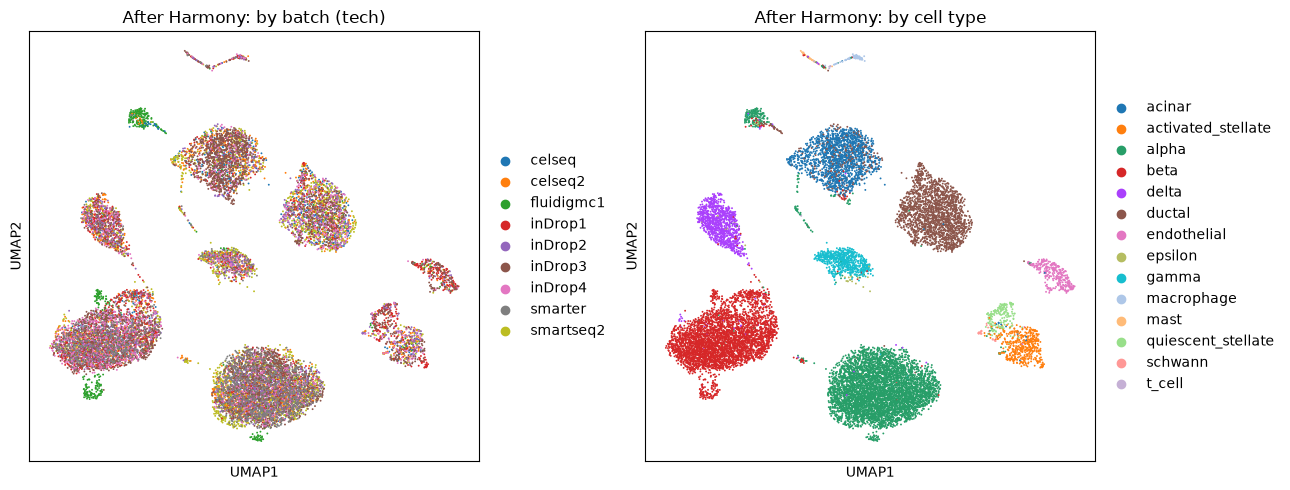

In [5]:
sc.pp.neighbors(adata_hvg, use_rep="X_pca_harmony")
sc.tl.umap(adata_hvg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata_hvg, color="tech", ax=axes[0], show=False, title="After Harmony: by batch (tech)")
sc.pl.umap(adata_hvg, color="celltype", ax=axes[1], show=False, title="After Harmony: by cell type")
plt.tight_layout()
plt.savefig("../results/figures/02_harmony_umap.png", dpi=150)
plt.show()

**What to look for, comparing with notebook 01:**
- Did the isolated islands (celseq/celseq2/smarter/smartseq2) collapse into the main
  cloud, or did Harmony fail to fix this particular case?
- Did the boundaries between different cell types blur in the process (a good integration
  removes the batch effect **without destroying** biological differences)?

## 5. Quick quantitative check (preliminary — the full comparison is in notebook 05)

We cluster the corrected space (Leiden) and compare the resulting clusters with the known
cell types via ARI/NMI — the closer to 1, the better the clusters match biology.

**On resolution, briefly**: rather than guessing one value, I sweep a small grid and
pick whatever maximizes agreement with the known cell types. Standard practice for
comparing integration methods (the scIB paper does this too), but it's tuning against a
known answer, not a fully unsupervised result — worth remembering when reading the
number below.

In [6]:
resolutions = [0.3, 0.5, 0.7, 1.0, 1.3]
sweep_results = []

for res in resolutions:
    sc.tl.leiden(
        adata_hvg, resolution=res, flavor="igraph", n_iterations=2,
        directed=False, key_added=f"leiden_r{res}",
    )
    ari = adjusted_rand_score(adata_hvg.obs["celltype"], adata_hvg.obs[f"leiden_r{res}"])
    nmi = normalized_mutual_info_score(adata_hvg.obs["celltype"], adata_hvg.obs[f"leiden_r{res}"])
    n_clusters = adata_hvg.obs[f"leiden_r{res}"].nunique()
    sweep_results.append({"resolution": res, "ARI": ari, "NMI": nmi, "n_clusters": n_clusters})

sweep_df = pd.DataFrame(sweep_results)
sweep_df

,resolution,ARI,NMI,n_clusters
0,0.3,0.914267,0.888037,12
1,0.5,0.885303,0.867960,16
2,0.7,0.775823,0.832568,17
3,1.0,0.579977,0.775674,20
4,1.3,0.465018,0.738594,24


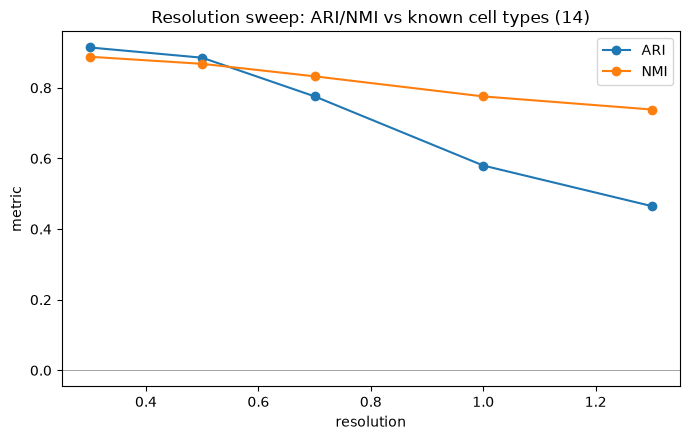

Best resolution: 0.3
ARI (Harmony vs celltype): 0.914
NMI (Harmony vs celltype): 0.888
Number of Leiden clusters: 12, known cell types: 14


In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_df["resolution"], sweep_df["ARI"], marker="o", label="ARI")
ax.plot(sweep_df["resolution"], sweep_df["NMI"], marker="o", label="NMI")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("resolution")
ax.set_ylabel("metric")
ax.set_title("Resolution sweep: ARI/NMI vs known cell types (14)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/02_resolution_sweep.png", dpi=150)
plt.show()

best_res = sweep_df.loc[sweep_df["ARI"].idxmax(), "resolution"]
adata_hvg.obs["leiden"] = adata_hvg.obs[f"leiden_r{best_res}"]
ari = sweep_df.loc[sweep_df["ARI"].idxmax(), "ARI"]
nmi = sweep_df.loc[sweep_df["ARI"].idxmax(), "NMI"]
print(f"Best resolution: {best_res}")
print(f"ARI (Harmony vs celltype): {ari:.3f}")
print(f"NMI (Harmony vs celltype): {nmi:.3f}")
print(f"Number of Leiden clusters: {adata_hvg.obs['leiden'].nunique()}, known cell types: {adata_hvg.obs['celltype'].nunique()}")

These ARI/NMI values are computed for Harmony at its best found resolution. In
notebook 05 we'll compute the same thing (also with a resolution sweep) for the baseline
(no integration), scVI, and scANVI, and combine everything into one table — that will show
whether DL methods actually improve on classic Harmony, or whether for this particular
dataset the difference is negligible (also a valid and interesting finding for the report —
"more complex method" doesn't have to mean "better").

## 6. Saving the result

In [8]:
adata_hvg.write("../data/processed/pancreas_harmony.h5ad")
print("Saved:", adata_hvg.shape)

Saved: (16382, 2000)


## Conclusions

Harmony: ARI = 0.914, NMI = 0.888 at resolution 0.3 (12 clusters against 14 known
types). The islands from the baseline UMAP mostly collapse into the main cell-type
clusters — not perfectly, but clearly better than doing nothing.

Worth mentioning since it happened to me: I initially saved this notebook's output
*before* running the resolution sweep, which meant the saved file was missing the
`leiden_r*` columns and Harmony silently dropped out of the notebook 05 comparison later.
Re-running top to bottom fixed it. Cheap lesson, annoying to debug.

Next: scVI, same evaluation setup, in `03_scvi.ipynb`.
